# gnomAD population-frequency EDA

gnomAD v4 (`gnomad_r4`, **GRCh38**) allele frequencies at expert-reviewed ClinVar SNVs.

These frequencies are **EDA-only**. They are **not** in `FEATURE_COLUMNS` / training / inference.
ClinVar pathogenic vs benign labels already use ACMG frequency evidence (BA1 / BS1 / PM2), so AF vs label will look strong without being independent biology.

```
python src/ingest_gnomad.py
python src/clean_gnomad.py
python src/join_clinvar_gnomad.py   # + --vus
```


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from features import FEATURE_COLUMNS, add_gnomad_features, prepare_modeling_frame
from ingest_gnomad import gnomad_variant_id

GNOMAD_CLEAN = project_root / "data/processed/gnomad_clean.parquet"
JOINED = project_root / "data/processed/clinvar_uniprot_gnomad_position_matched.parquet"
CLINVAR_CLEAN = project_root / "data/processed/clinvar_clean.parquet"
POSITION_MATCHED = project_root / "data/processed/clinvar_uniprot_position_matched.parquet"

sns.set_theme(style="whitegrid")


## 1. Assembly is already GRCh38 — and labels are expert review

ClinVar ingest keeps `Assembly == "GRCh38"` **and** `ReviewStatus` in `{reviewed by expert panel, practice guideline}`.
gnomAD v4 is GRCh38. Mixing in hg19 would attach frequencies to the **wrong base pair** (same `Start`, different locus). No extra assembly filter is needed on the gnomAD side.

Labels **are** clinician/expert-panel review. Those panels use the ACMG/AMP checklist; population frequency is one of the strongest items on that checklist (next section). Expert review does **not** mean the labels are independent of gnomAD.


In [2]:
clinvar = pd.read_parquet(CLINVAR_CLEAN)
print("ClinVar labelled Assembly:")
print(clinvar["Assembly"].value_counts(dropna=False).to_string())
print()
print("ReviewStatus (expert-panel / guideline only):")
print(clinvar["ReviewStatus"].value_counts(dropna=False).to_string())
print()
print("gnomAD dataset in ingest: gnomad_r4 (GRCh38)")
assert clinvar["Assembly"].nunique() == 1
assert set(clinvar["Assembly"].unique()) == {"GRCh38"}


ClinVar labelled Assembly:
Assembly
GRCh38    11635

ReviewStatus (expert-panel / guideline only):
ReviewStatus
reviewed by expert panel    11616
practice guideline             19

gnomAD dataset in ingest: gnomad_r4 (GRCh38)


## 2. Join key is ClinVar genomic coordinates, not UniProt

UniProt has domains and amino-acid sites, **not** allele frequencies. `join_clinvar_gnomad.py` left-joins onto the ClinVar–UniProt position-matched table only because that is the working table. The key is still ClinVar:

`Chromosome`, `Start`, `ReferenceAlleleVCF`, `AlternateAlleleVCF` → `chrom-pos-ref-alt` (mito `MT` → `M`).

UniProt-only rows have no chr/pos/alleles, so they stay `in_gnomad=False`.


In [3]:
joined = pd.read_parquet(JOINED)
print("join_type on the gnomAD-enriched table:")
print(joined["match_type"].value_counts().to_string())
print()
print("Example ClinVar locus → gnomAD id:")
row = clinvar.iloc[0]
vid = gnomad_variant_id(row.Chromosome, row.Start, row.ReferenceAlleleVCF, row.AlternateAlleleVCF)
print(
    f"  chr{row.Chromosome}:{int(row.Start)} {row.ReferenceAlleleVCF}>{row.AlternateAlleleVCF}"
    f"  →  {vid}"
)

mt = clinvar[clinvar["Chromosome"].astype(str) == "MT"].iloc[0]
print()
print("Mito remap MT → M (gnomAD uses M, ClinVar uses MT):")
print(
    f"  ClinVar {mt.Chromosome}:{int(mt.Start)} {mt.ReferenceAlleleVCF}>{mt.AlternateAlleleVCF}"
    f"  →  {gnomad_variant_id(mt.Chromosome, mt.Start, mt.ReferenceAlleleVCF, mt.AlternateAlleleVCF)}"
)

has_key = joined["gnomad_variant_id"].notna()
print()
print("Rows with a genomic key:", int(has_key.sum()), "/", len(joined))
print("of which match_type:")
print(joined.loc[has_key, "match_type"].value_counts().to_string())
print()
print(
    "UniProt-only rows with a gnomAD id (should be 0):",
    int((joined["match_type"].eq("uniprot_only") & has_key).sum()),
)


join_type on the gnomAD-enriched table:
match_type
both            11586
uniprot_only     5188
clinvar_only       89

Example ClinVar locus → gnomAD id:
  chr12:6018535 A>G  →  12-6018535-A-G

Mito remap MT → M (gnomAD uses M, ClinVar uses MT):
  ClinVar MT:1624 C>T  →  M-1624-C-T

Rows with a genomic key: 11675 / 16863
of which match_type:
match_type
both            11586
clinvar_only       89

UniProt-only rows with a gnomAD id (should be 0): 0


## 3. gnomAD is EDA-only — not worth training on

Training reads `clinvar_uniprot_position_matched.parquet` (no AF). `FEATURE_COLUMNS` has no gnomAD names.

**Why drop it:** BA1/BS1/PM2 are already inside the ClinVar P/B labels. A model that sees AF is mostly recovering the ACMG rubric, not new protein biology. Gene-holdout CV does **not** fix it — rarity is not gene-specific. Keep the frequencies here for QC and for reading ClinVar, not as predictors.


In [4]:
print("FEATURE_COLUMNS (training):")
for c in FEATURE_COLUMNS:
    print(" ", c)
print()
print(
    "Any gnomAD name in the model matrix?",
    any("gnomad" in c.lower() for c in FEATURE_COLUMNS),
)
print("Training table:", POSITION_MATCHED.name)


FEATURE_COLUMNS (training):
  protein_position
  relative_protein_position
  distance_to_closest_feature
  has_protein_position
  in_domain
  in_region
  in_zinc_finger
  in_active_site
  in_binding_site
  in_disulfide
  in_mod_res
  in_functional_site
  in_any_feature
  closest_feature_type
  ReferenceAlleleVCF
  AlternateAlleleVCF

Any gnomAD name in the model matrix? False
Training table: clinvar_uniprot_position_matched.parquet


## 4. Found vs absent

**Absent** (`in_gnomad=False`) means: we queried this ClinVar SNV and gnomAD v4 did not return it as a site. That is *not* the same as “AF = 0 at a well-called position,” and it is **not conservation** (conservation is cross-species: phyloP/GERP). Absence can be purifying selection, a private/unsampled variant, or a coverage/calling hole.

Most possible SNVs in the genome are absent from gnomAD simply because they have never been observed.


Queried ClinVar SNVs (labelled + VUS): 15241
  present: 9717 (63.8%)
  absent:  5524 (36.2%)

AF among found sites:


count    9717.000000
mean        0.019463
std         0.091779
min         0.000000
50%         0.000009
90%         0.007176
99%         0.491995
max         0.999517

FILTER PASS among found sites: 78.8%  (QC flag on the cleaned table, not a derived feature)


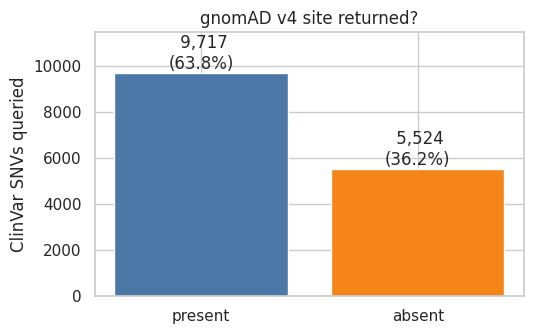

In [5]:
gnomad = pd.read_parquet(GNOMAD_CLEAN)
n_query = len(gnomad)
n_abs = int((~gnomad["in_gnomad"]).sum())
print(f"Queried ClinVar SNVs (labelled + VUS): {n_query}")
print(f"  present: {int(gnomad.in_gnomad.sum())} ({gnomad.in_gnomad.mean():.1%})")
print(f"  absent:  {n_abs} ({n_abs / n_query:.1%})")

found = gnomad.loc[gnomad["in_gnomad"], "gnomad_af"]
print()
print("AF among found sites:")
print(found.describe(percentiles=[0.5, 0.9, 0.99]).to_string())
print()
print(
    "FILTER PASS among found sites:",
    f"{gnomad.loc[gnomad.in_gnomad, 'gnomad_filter_pass'].mean():.1%}"
    "  (QC flag on the cleaned table, not a derived feature)",
)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
counts = gnomad["in_gnomad"].value_counts().rename({True: "present", False: "absent"})
ax.bar(counts.index.astype(str), counts.values, color=["#4c78a8", "#f58518"])
ax.set_ylabel("ClinVar SNVs queried")
ax.set_title("gnomAD v4 site returned?")
for i, v in enumerate(counts.values):
    ax.text(i, v, f" {v:,}\n({v / n_query:.1%})", ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()


## 5. Why AF vs label looks so strong (circularity)

ClinVar labels in this project **are** expert-panel review. Those panels use the ACMG/AMP checklist. Population frequency is one of the strongest items:

| code | meaning | rule of thumb |
|---|---|---|
| **BA1** | stand-alone benign | AF ≳ **5%** in a general population |
| **BS1** | strong benign | AF higher than expected for the disorder (often ≳ **1%**) |
| **PM2** | moderate pathogenic | absent or extremely rare in gnomAD |

Putting gnomAD AF into a classifier recovers that rubric. Gene-holdout does **not** fix it: rarity is not gene-specific.


Modeling rows (UniProt-matched P/B, one per VariationID): 11563

               n  n_absent  pct_absent  pct_in_gnomad  median_af  median_af_if_present
label                                                                                 
benign      5211       493    9.460756      90.539244   0.000059              0.000110
pathogenic  6352      3468   54.596977      45.403023   0.000000              0.000002

Overall absent on modeling rows: 34.3% (3961/11563)


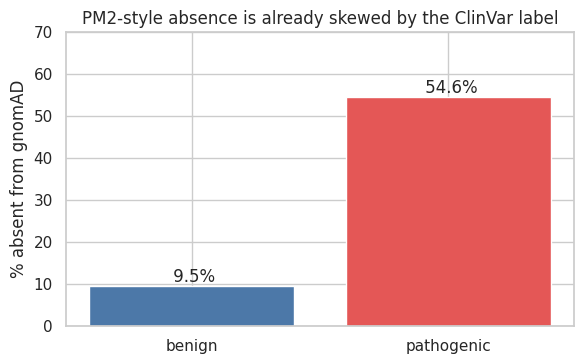

In [6]:
model = add_gnomad_features(prepare_modeling_frame(joined))
print("Modeling rows (UniProt-matched P/B, one per VariationID):", len(model))
print()
by_label = model.groupby("label").agg(
    n=("VariationID", "size"),
    n_absent=("in_gnomad", lambda s: int((~s).sum())),
    pct_absent=("in_gnomad", lambda s: 100 * (~s).mean()),
    pct_in_gnomad=("in_gnomad", lambda s: 100 * s.mean()),
    median_af=("gnomad_af", "median"),
)
found_med = (
    model[model.in_gnomad].groupby("label")["gnomad_af"].median().rename("median_af_if_present")
)
by_label = by_label.join(found_med)
print(by_label.to_string())
print()
print(
    "Overall absent on modeling rows:",
    f"{100 * (~model.in_gnomad).mean():.1f}% ({int((~model.in_gnomad).sum())}/{len(model)})",
)

fig, ax = plt.subplots(figsize=(6, 3.8))
pct = model.groupby("label")["in_gnomad"].agg(lambda s: 100 * (~s).mean())
colors = ["#4c78a8" if i == "benign" else "#e45756" for i in pct.index]
ax.bar(pct.index.astype(str), pct.values, color=colors)
ax.set_ylabel("% absent from gnomAD")
ax.set_title("PM2-style absence is already skewed by the ClinVar label")
for i, v in enumerate(pct.values):
    ax.text(i, v, f" {v:.1f}%", ha="center", va="bottom")
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()


Counts (BA1 = AF ≥ 5% should be ~all benign):
label                 benign  pathogenic  pct_pathogenic
gnomad_af_bin                                           
absent                   493        3468            87.6
singleton_or_private    1318        2293            63.5
ultra_rare              1005         486            32.6
rare                     823          87             9.6
low_freq                 737          17             2.3
common_bs1               288           1             0.3
common_ba1               547           0             0.0

BA1 (AF ≥ 5%): 547 benign / 0 pathogenic


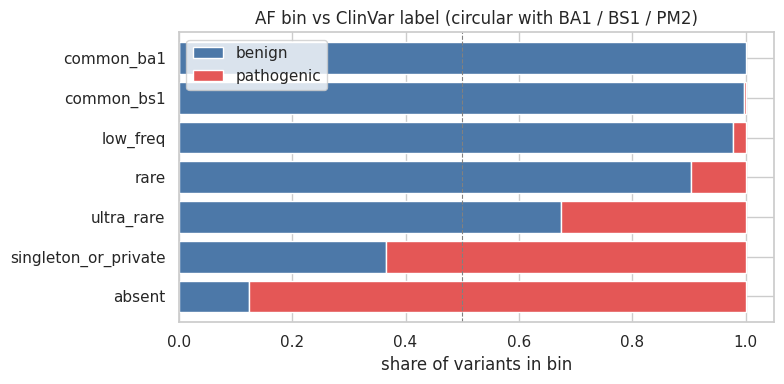

In [7]:
bin_order = [
    "absent", "singleton_or_private", "ultra_rare", "rare",
    "low_freq", "common_bs1", "common_ba1",
]
ct = pd.crosstab(model["gnomad_af_bin"], model["label"]).reindex(bin_order)
ct["pct_pathogenic"] = (ct["pathogenic"] / ct.sum(axis=1) * 100).round(1)
print("Counts (BA1 = AF ≥ 5% should be ~all benign):")
print(ct.to_string())
print()
print(
    "BA1 (AF ≥ 5%):",
    f"{int(ct.loc['common_ba1', 'benign'])} benign / "
    f"{int(ct.loc['common_ba1', 'pathogenic'])} pathogenic",
)

fig, ax = plt.subplots(figsize=(8, 4))
frac = pd.crosstab(model["gnomad_af_bin"], model["label"], normalize="index").reindex(bin_order)
frac.plot(kind="barh", stacked=True, ax=ax, color=["#4c78a8", "#e45756"], width=0.8)
ax.set_xlabel("share of variants in bin")
ax.set_ylabel("")
ax.set_title("AF bin vs ClinVar label (circular with BA1 / BS1 / PM2)")
ax.legend(title="")
ax.axvline(0.5, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.show()


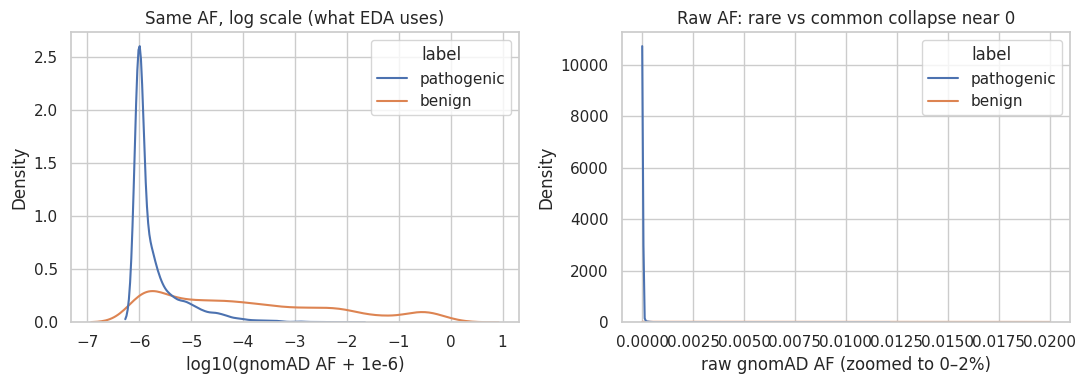

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(
    data=model, x="log10_gnomad_af", hue="label",
    common_norm=False, ax=axes[0],
)
axes[0].set_xlabel("log10(gnomAD AF + 1e-6)")
axes[0].set_title("Same AF, log scale (what EDA uses)")

sns.kdeplot(
    data=model, x="gnomad_af", hue="label",
    common_norm=False, ax=axes[1], clip=(0, 0.02),
)
axes[1].set_xlabel("raw gnomAD AF (zoomed to 0–2%)")
axes[1].set_title("Raw AF: rare vs common collapse near 0")
plt.tight_layout()
plt.show()


## 6. Absence is not conservation

Conservation = the base/residue stayed the same **across species**. gnomAD absence = this alt was not in ~800k sequenced people.

Both pathogenic and benign ClinVar SNVs can be absent. Pathogenic are *more often* absent (selection), which **correlates** with conservation but is a different measurement. ACMG **PM2** treats rarity as moderate evidence only together with other evidence.

If absence meant “must be conserved / pathogenic,” the benign-absent count below would be zero — it is not.


Absent modeling variants by label (same 'not in gnomAD' status):
label
pathogenic    3468
benign         493

Benign variants that are absent (not 'must be conserved'): 493
Pathogenic variants that *are* in gnomAD (not 'must be missing'): 2884


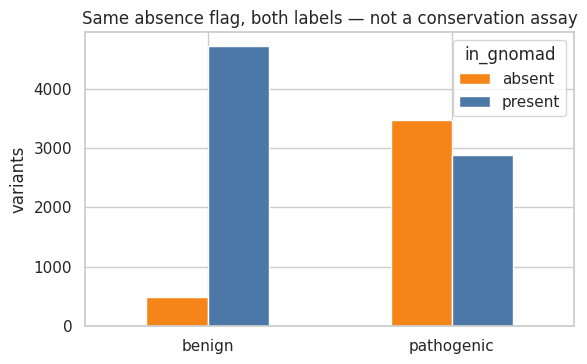

In [9]:
print("Absent modeling variants by label (same 'not in gnomAD' status):")
print(model.loc[~model.in_gnomad, "label"].value_counts().to_string())
print()
n_ben_abs = int(((~model.in_gnomad) & (model.label == "benign")).sum())
n_path_present = int((model.in_gnomad & (model.label == "pathogenic")).sum())
print("Benign variants that are absent (not 'must be conserved'):", n_ben_abs)
print("Pathogenic variants that *are* in gnomAD (not 'must be missing'):", n_path_present)

fig, ax = plt.subplots(figsize=(6, 3.8))
tab = pd.crosstab(model["label"], model["in_gnomad"].map({True: "present", False: "absent"}))
tab = tab[["absent", "present"]]
tab.plot(kind="bar", ax=ax, color=["#f58518", "#4c78a8"], rot=0)
ax.set_ylabel("variants")
ax.set_xlabel("")
ax.set_title("Same absence flag, both labels — not a conservation assay")
plt.tight_layout()
plt.show()


## 7. What AF = 0.06 means in people

gnomAD counts **chromosome copies**, not people. Humans are diploid (two copies of most chromosomes).

- AF `0.06` → 6 of 100 chromosome copies have the alt.
- If every carrier is a **heterozygote**, each person contributes 1 of their 2 copies → **~12% of people** (`2p`).
- Hardy–Weinberg is the precise split: heterozygotes `2p(1-p)`, homozygotes `p²`.

For ultra-rare AF (e.g. 2×10⁻⁶), `2p` is an excellent approximation and homozygotes are essentially none. At 6%, homozygotes are real.


AF p = 0.06
  shortcut 2p (all heterozygous): 12.0% of people
  HWE heterozygotes 2p(1-p):      11.3%
  HWE homozygotes p²:             0.36%
  HWE any alt 1-(1-p)²:           11.6%

Example common benign in this table:
  NM_000545.8(HNF1A):c.1720A>G (p.Ser574Gly)
  AF=0.9975  nhomalt=802,494  (homozygotes exist)


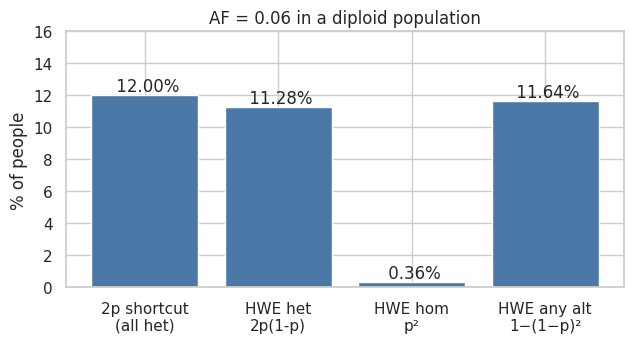

In [10]:
p = 0.06
hwe = pd.Series(
    {
        "2p shortcut\n(all het)": 2 * p,
        "HWE het\n2p(1-p)": 2 * p * (1 - p),
        "HWE hom\np²": p ** 2,
        "HWE any alt\n1−(1−p)²": 1 - (1 - p) ** 2,
    }
)
print(f"AF p = {p}")
print(f"  shortcut 2p (all heterozygous): {2 * p:.1%} of people")
print(f"  HWE heterozygotes 2p(1-p):      {2 * p * (1 - p):.1%}")
print(f"  HWE homozygotes p²:             {p ** 2:.2%}")
print(f"  HWE any alt 1-(1-p)²:           {1 - (1 - p) ** 2:.1%}")

ex = model[model["gnomad_af_bin"] == "common_ba1"].nlargest(1, "gnomad_nhomalt").iloc[0]
print()
print("Example common benign in this table:")
print(f"  {ex.Name}")
print(f"  AF={ex.gnomad_af:.4f}  nhomalt={int(ex.gnomad_nhomalt):,}  (homozygotes exist)")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(hwe.index, 100 * hwe.values, color="#4c78a8")
ax.set_ylabel("% of people")
ax.set_title("AF = 0.06 in a diploid population")
for i, v in enumerate(hwe.values):
    ax.text(i, 100 * v, f" {100 * v:.2f}%", ha="center", va="bottom")
ax.set_ylim(0, 16)
plt.tight_layout()
plt.show()


## 8. Preferred frequency: joint, else exome, else genome

This is a **sample-size / coverage** rule, not three different biological truths.

gnomAD v4 is two experiments:

- **Exomes** — ~731k people, coding capture (where most of this ClinVar set lives)
- **Genomes** — ~76k people, whole genome, ~10× fewer samples
- **Joint** — official combine (largest `AN` = chromosomes sequenced)

`clean_gnomad.py` prefers joint, then exome, then genome. A singleton in genomes is AF ≈ 1/152k; in joint it is ≈ 1/1.6M. Those are different PM2-style statements. In *this* download the fallback never fired: every found site has joint.


Which callset supplies preferred AF among found sites:
af_source
joint    9717

Share with each AN:
  joint   100.0%   median AN 1613162
  exome    89.4%   median AN 1461218
  genome   63.5%   median AN 152176


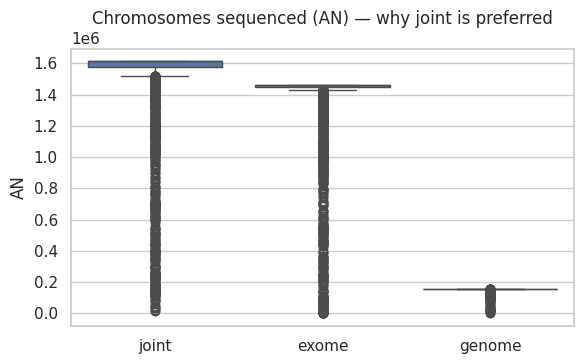

In [11]:
found_g = gnomad[gnomad["in_gnomad"]].copy()


def source(row):
    if pd.notna(row.joint_an):
        return "joint"
    if pd.notna(row.exome_an):
        return "exome"
    if pd.notna(row.genome_an):
        return "genome"
    return "none"


found_g["af_source"] = found_g.apply(source, axis=1)
print("Which callset supplies preferred AF among found sites:")
print(found_g["af_source"].value_counts().to_string())
print()
print("Share with each AN:")
for col, name in [("joint_an", "joint"), ("exome_an", "exome"), ("genome_an", "genome")]:
    print(f"  {name:6s}  {found_g[col].notna().mean():6.1%}   median AN {found_g[col].median():.0f}")

an = found_g[["joint_an", "exome_an", "genome_an"]].melt(var_name="callset", value_name="AN")
an["callset"] = an["callset"].str.replace("_an", "")
fig, ax = plt.subplots(figsize=(6, 3.8))
sns.boxplot(data=an.dropna(), x="callset", y="AN", ax=ax, order=["joint", "exome", "genome"])
ax.set_title("Chromosomes sequenced (AN) — why joint is preferred")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 9. Discordant exome vs genome AF

Exome AF and genome AF are **two different experiments** (different people, capture vs PCR-free, different callers). They need not match. Ancestry mix differs; capture misses some exons; paralogs/segdups can inflate one callset; one pipeline may fail `AS_VQSR`.

gnomAD v4.1 flags ~2.5% of *all* sites as statistically discordant after ancestry adjustment. Relative AF can also look large for ultra-rare variants just from Poisson noise (2 counts vs 0).


Sites with both exome and genome AF: 5144
  median |exome − genome|: 2.34e-05
  fraction 10× apart (log10 ratio > 1): 7.4%
  fraction |ΔAF| > 1 percentage point: 6.7%

Striking discordance (well-called, still far apart) — mapping/VQSR, not two biologies:
gnomad_variant_id  exome_af  genome_af  joint_af exome_filters genome_filters
  21-34792318-G-C  0.001418   0.000007  0.001276                      AS_VQSR
  21-34792313-T-C  0.001030   0.000007  0.000914                             
  21-34792308-A-G  0.005948   0.000055  0.005200                      AS_VQSR
  21-34792306-C-G  0.002807   0.000027  0.002509       AS_VQSR        AS_VQSR
  21-34792315-G-C  0.000365   0.000007  0.000330                             
   1-68444607-C-T  0.000003   0.000125  0.000014                             
  21-34792326-T-A  0.001572   0.000035  0.001406       AS_VQSR        AS_VQSR
  13-32340031-T-G  0.000188   0.000007  0.000171       AS_VQSR        AS_VQSR

Joint smears the two: it is close to the l

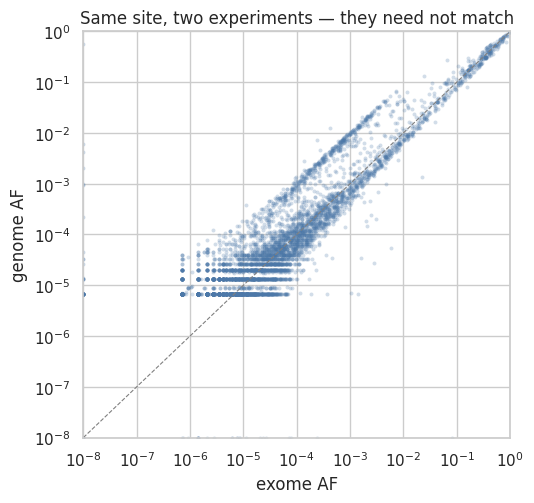

In [12]:
both = found_g[found_g.exome_af.notna() & found_g.genome_af.notna()].copy()
both["abs_diff"] = (both.exome_af - both.genome_af).abs()
both["rel"] = both.abs_diff / ((both.exome_af + both.genome_af) / 2 + 1e-12)
log_ratio = np.abs(np.log10((both.exome_af + 1e-12) / (both.genome_af + 1e-12)))
print(f"Sites with both exome and genome AF: {len(both)}")
print(f"  median |exome − genome|: {both.abs_diff.median():.2e}")
print(f"  fraction 10× apart (log10 ratio > 1): {(log_ratio > 1).mean():.1%}")
print(f"  fraction |ΔAF| > 1 percentage point: {(both.abs_diff > 0.01).mean():.1%}")

show = both[
    (both.exome_an > 1e5)
    & (both.genome_an > 5e4)
    & (both.rel > 1)
    & ((both.exome_af > 1e-4) | (both.genome_af > 1e-4))
].sort_values("rel", ascending=False)
print()
print("Striking discordance (well-called, still far apart) — mapping/VQSR, not two biologies:")
cols = [
    "gnomad_variant_id", "exome_af", "genome_af", "joint_af",
    "exome_filters", "genome_filters",
]
print(show[cols].head(8).to_string(index=False))
print()
print("Joint smears the two: it is close to the larger callset, not a third truth.")

fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.scatter(
    both.exome_af + 1e-8, both.genome_af + 1e-8,
    s=8, alpha=0.25, c="#4c78a8", linewidths=0,
)
lims = (1e-8, 1)
ax.plot(lims, lims, color="grey", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("exome AF")
ax.set_ylabel("genome AF")
ax.set_title("Same site, two experiments — they need not match")
plt.tight_layout()
plt.show()


## 10. Four variants + popmax

`add_gnomad_features()` is only for these plots (absent AF filled to 0 so log10 sits at −6). **Not** in `FEATURE_COLUMNS`.

In [13]:
# Same four variants as earlier in this thread.
wanted = [
    ("pathogenic, absent", "p.Trp1313Cys"),
    ("pathogenic, singleton", "p.Ile1628Thr"),
    ("benign, low_freq", "p.Met1040Val"),
    ("benign, common_ba1", "p.Lys80Arg"),
]
cols = [
    "Name", "label", "in_gnomad", "gnomad_af", "gnomad_af_popmax",
    "gnomad_nhomalt", "log10_gnomad_af", "gnomad_af_bin",
]
rows = []
for title, aa in wanted:
    r = model[model["Name"].astype(str).str.contains(aa, na=False)].iloc[0]
    d = {c: r[c] for c in cols}
    d["story"] = title
    rows.append(d)
ex = pd.DataFrame(rows).set_index("story")
pd.set_option("display.max_colwidth", 70)
print(ex.to_string())
print()
print("In words:")
print("  VWF p.Trp1313Cys  — never seen in gnomAD (AF treated as 0, log10 = −6)")
print("  VWF p.Ile1628Thr  — ~2 per million chromosomes")
print("  ATM p.Met1040Val  — ~2 per thousand  (popmax is much higher — next cell)")
print("  ADA p.Lys80Arg    — common (~6% of chromosomes ≈ 12% of people if het)")


                                                            Name       label  in_gnomad  gnomad_af  gnomad_af_popmax  gnomad_nhomalt  log10_gnomad_af         gnomad_af_bin
story                                                                                                                                                                      
pathogenic, absent     NM_000552.5(VWF):c.3939G>C (p.Trp1313Cys)  pathogenic      False   0.000000      0.000000e+00             0.0        -6.000000                absent
pathogenic, singleton  NM_000552.5(VWF):c.4883T>C (p.Ile1628Thr)  pathogenic       True   0.000002      2.800000e-07             0.0        -5.543799  singleton_or_private
benign, low_freq       NM_000051.4(ATM):c.3118A>G (p.Met1040Val)      benign       True   0.002097      3.851756e-02            67.0        -2.678208              low_freq
benign, common_ba1        NM_000022.4(ADA):c.239A>G (p.Lys80Arg)      benign       True   0.060018      1.046273e-01          3190.0        

Global AF vs popmax (BA1/BS1 care about the higher number):
  NM_000051.4(ATM):c.3118A>G (p.Met1040Val)
  global AF=0.0021   popmax=0.0385   (18.4×)


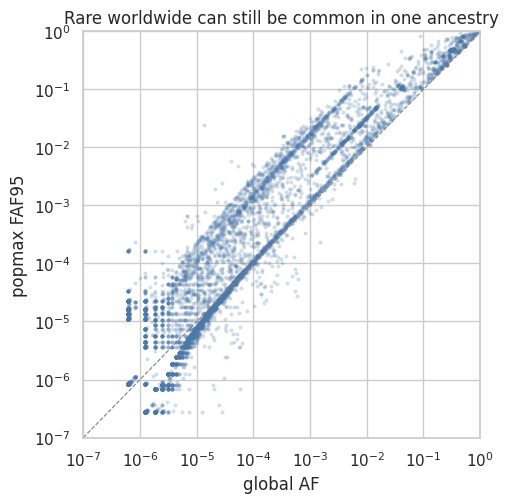

In [14]:
# popmax vs global: a variant can be rare worldwide but common in one ancestry.
# BA1/BS1 care about the higher number (FAF95 popmax), not the world average.
gap = model[model.in_gnomad].assign(
    popmax_ratio=lambda d: d.gnomad_af_popmax / d.gnomad_af.replace(0, np.nan)
)
row = gap[gap.gnomad_af.between(0.001, 0.01) & (gap.popmax_ratio > 5)].iloc[0]
print("Global AF vs popmax (BA1/BS1 care about the higher number):")
print(f"  {row.Name}")
print(
    f"  global AF={row.gnomad_af:.4f}   popmax={row.gnomad_af_popmax:.4f}"
    f"   ({row.popmax_ratio:.1f}×)"
)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
plot = gap[(gap.gnomad_af > 0) & (gap.gnomad_af_popmax > 0)]
ax.scatter(
    plot.gnomad_af, plot.gnomad_af_popmax,
    s=8, alpha=0.25, c="#4c78a8", linewidths=0,
)
lims = (1e-7, 1)
ax.plot(lims, lims, color="grey", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("global AF")
ax.set_ylabel("popmax FAF95")
ax.set_title("Rare worldwide can still be common in one ancestry")
plt.tight_layout()
plt.show()
